/tmp/ipykernel_710783/2664724227.py:5: DtypeWarning: Columns (38,39,41,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_abl1 = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/ABL1/ensembl_library_with_predictions.csv")
/tmp/ipykernel_710783/2664724227.py:6: DtypeWarning: Columns (38,39,41,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dyrk1a = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A/ensembl_library_with_predictions.csv")
/tmp/ipykernel_710783/2664724227.py:7: DtypeWarning: Columns (38,39,41,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ttbk1 = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/TTBK1/ttbk1_final/ensemble_library_with_predictions.csv")


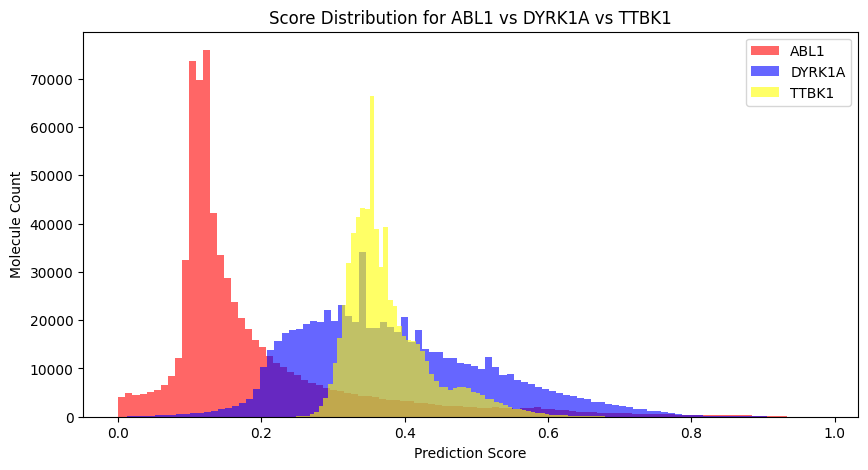

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Load prediction results
df_abl1 = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/ABL1/ensembl_library_with_predictions.csv")
df_dyrk1a = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A/ensembl_library_with_predictions.csv")
df_ttbk1 = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/TTBK1/ttbk1_final/ensemble_library_with_predictions.csv")

plt.figure(figsize=(10,5))

plt.hist(df_abl1["pred_score"], bins=100, alpha=0.6, label="ABL1", color='red')
plt.hist(df_dyrk1a["pred_score"], bins=100, alpha=0.6, label="DYRK1A", color='blue')
plt.hist(df_ttbk1["pred_score"], bins=100, alpha=0.6, label="TTBK1", color='yellow')

plt.xlabel("Prediction Score")
plt.ylabel("Molecule Count")
plt.title("Score Distribution for ABL1 vs DYRK1A vs TTBK1")
plt.legend()
plt.grid(False)
plt.show()


In [ ]:
#imPORTANT- FINDING COMMONS FOR mt WITH AVG PREDICTION SCORE
import os
import pandas as pd

#  Setup ───
os.chdir("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT")

library_file = "coconut_csv-06-2025.csv"
library_df = (
    pd.read_csv(library_file, usecols=["Identifier", "canonical_smiles", "name"])
      .rename(columns={"Identifier": "identifier"})
)

target_info = {
    "ABL1":   "ABL1/ensembl_library_with_predictions.csv",
    "DYRK1A": "DYRK1A/ensembl_library_with_predictions.csv",
    "TTBK1":  "TTBK1/ttbk1_final/ensemble_library_with_predictions.csv"
}

#  Load & merge prediction scores ────
# Read each prediction file into a DataFrame, rename the score column, and store in a list
pred_dfs = []
for target, path in target_info.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing prediction file for {target}: {path}")
    df = pd.read_csv(path, usecols=["identifier", "pred_score"])
    df = df.rename(columns={"pred_score": f"pred_score_{target}"})
    pred_dfs.append(df)

# Merge all predictions on 'identifier'
all_preds = pred_dfs[0]
for df in pred_dfs[1:]:
    all_preds = all_preds.merge(df, on="identifier", how="inner")

#Compute average score ─────────────────────────────────────────────────
score_cols = [f"pred_score_{t}" for t in target_info]
all_preds["avg_score"] = all_preds[score_cols].mean(axis=1)

# Save the full table with individual scores + average
all_preds.to_csv("all_scores_with_avg.csv", index=False)
print(f"✅ Saved {len(all_preds)} rows to all_scores_with_avg.csv")

# Apply a single cutoff on the average score ──────────────────────────
cutoff = 0.5  
hits = all_preds[all_preds["avg_score"] >= cutoff]

# Merge with library metadata
hits = hits.merge(library_df, on="identifier", how="left")

# Save the final hits
hits.to_csv("average_hits_MT.csv", index=False)
print(f"✅ Saved {len(hits)} multi-target hits (avg_score ≥ {cutoff}) to multi_target_hits.csv")


✅ Saved 695119 rows to all_scores_with_avg.csv
✅ Saved 11502 multi-target hits (avg_score ≥ 0.5) to multi_target_hits.csv


In [ ]:
# final_df["canonical smiles"].to_csv("multi_target_YoudenJ_only smiles.csv", index=False)
final_df[["canonical_smiles", "identifier"]].to_csv("multi_target_hits_remaining.smi", sep=" ", index=False, header=False)


print(final_df[['identifier', 'name']].head())
print("Columns in final_df:", final_df.columns.tolist())


     identifier            name
0  CNP0074467.1    ETHOXARUTINE
1  CNP0074465.1  Estrapronicate
2  CNP0074332.1      EVODENOSON
3  CNP0320834.1       Gimatecan
4  CNP0074586.1     Pegamotecan
Columns in final_df: ['identifier', 'pred_score_ABL1', 'pred_score_DYRK1A', 'pred_score_TTBK1', 'canonical_smiles', 'name']


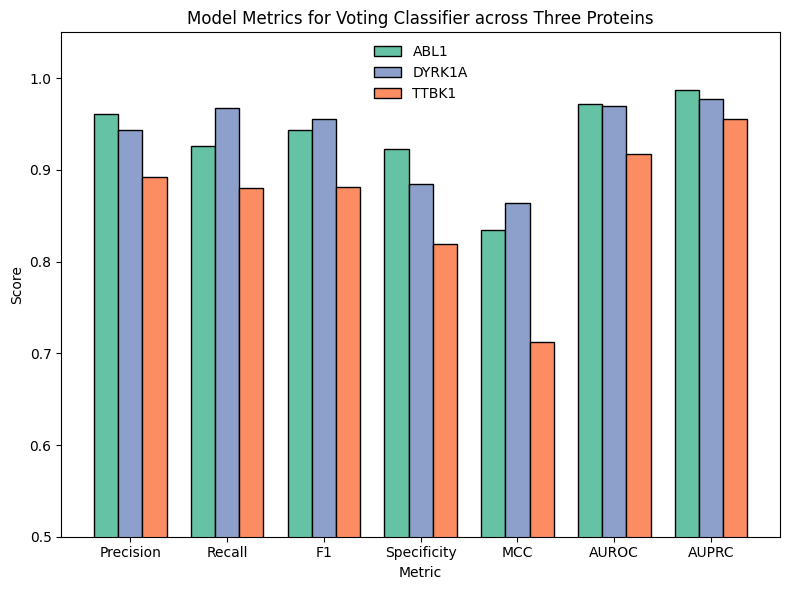

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example data (means only)
data = {
    'Metric': ['Precision','Recall','F1','Specificity','MCC','AUROC','AUPRC'],
    'ABL1_mean': [0.961,0.926,0.943,0.923,0.8343,0.972,0.987],
    'DYRK1A_mean':[ 0.943,0.967,0.955,0.885,0.864,0.970,0.977],
    'TTBK1_mean': [0.892,0.880,0.881,0.819,0.712,0.917,0.955]
}
df = pd.DataFrame(data)

metrics = df['Metric']
x = np.arange(len(metrics))  # label locations
width = 0.25  # bar width

fig, ax = plt.subplots(figsize=(8, 6))

offsets = [-width, 0, width]
colors = ['#66c2a5', '#8da0cb', '#fc8d62']
labels = ['ABL1', 'DYRK1A', 'TTBK1']

for offset, color, label in zip(offsets, colors, labels):
    means = df[f'{label}_mean']
    # Plot bars without error bars
    ax.bar(x + offset, means, width, label=label, color=color, edgecolor='black')

# Set x-axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_xlabel('Metric')
# ax.set_title('Model Metrics for Voting Classifier across Three Proteins')
ax.set_ylim(0.5, 1.05)
ax.legend(loc='upper center', frameon=False, ncol=1)
ax.set_title('Model Metrics for Voting Classifier across Three Proteins')
plt.savefig("Metrics.png",dpi=300)


plt.tight_layout()
plt.show()
